In [8]:
import os
import numpy as np
import pandas as pd
import nibabel as nb
from nilearn.plotting import view_surf
import Functional_Fusion.dataset as fdata # from functional fusion module
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.data as cdata
import cortico_cereb_connectivity.cio as cio
import cortico_cereb_connectivity.summarize as cs
import cortico_cereb_connectivity.scripts.script_plotting_utils as plu
import seaborn as sns
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
import nitools as nt
from pathlib import Path
import warnings

In [19]:
traindata = gl.traindata_string(None)
cortex_roi = "Icosahedron1002"
cerebellum_roi = "NettekovenSym32"
agg_domain = False
method = 'L2reg'
ex = 'A2_global'
if agg_domain:
    fname = gl.conn_dir + f'/maps/{traindata}_{cortex_roi}_Nettekoven4Domains_{method}_mean.pscalar.nii'
    oname = f'{traindata}_{cortex_roi}_Nettekoven4Domains_{method}_mean.dscalar.nii'
else:
    fname = gl.conn_dir + f'/maps/{traindata}_{cortex_roi}_{cerebellum_roi}_{method}_mean.pscalar.nii'
    oname = f'{traindata}_{cortex_roi}_{cerebellum_roi}_{method}_mean.dscalar.nii'

In [ ]:
cifti_img = cs.avrg_weight_map_roi(traindata=traindata,
                                   cortex_roi=cortex_roi,
                                   method=method,
                                   extension=ex,
                                   cerebellum_roi=cerebellum_roi,
                                   agg_domain=agg_domain,
                                   norm=True)
cifti_img_new = cs.sort_roi_rows(cifti_img)
nb.save(cifti_img_new, fname)

In [20]:
cifti_img_new = nb.load(fname)
labels = cifti_img_new.header.get_axis(0).name
# index,colors,labels = nt.read_lut(gl.atlas_dir + f"/tpl-MNI152NLin2009cSymC/atl-{cerebellum_roi}.lut")

In [21]:
# smooth the cifti
cs.pscalar_to_smoothed_dscalar(cifti_img_new, oname, sigma=2.0)

wb_command -cifti-smoothing 'temp.dscalar.nii' 2.0 0.0 COLUMN /cifs/diedrichsen/data/Cerebellum/connectivity/maps/MdWfIbDeHtNiSoScLa_Icosahedron1002_NettekovenSym32_L2reg_mean.dscalar.nii -left-surface /cifs/diedrichsen/data/FunctionalFusion_new/Atlases/tpl-fs32k/tpl-fs32k_hemi-L_inflated.surf.gii -right-surface /cifs/diedrichsen/data/FunctionalFusion_new/Atlases/tpl-fs32k/tpl-fs32k_hemi-R_inflated.surf.gii


In [8]:
def make_cifti_subset(cifti_img, region_index):
    data = cifti_img.get_fdata()
    
    # Keep the selected row as (1, n_brainordinates)
    row = data[region_index:region_index + 1, :]

    # Get the two CIFTI axes
    axis0 = cifti_img.header.get_axis(0)
    axis1 = cifti_img.header.get_axis(1)

    # Subset only the first axis
    new_axis0 = axis0[region_index:region_index + 1]

    # Construct a header with the correct axes
    header = nb.cifti2.Cifti2Header.from_axes(
        (new_axis0, axis1)
    )

    img = nb.Cifti2Image(
        row,
        header=header,
        nifti_header=cifti_img.nifti_header
    )

    return img

In [9]:
for i, label in enumerate(labels):
    print(f"Label {i+1}: {label}")
    cifti_img_region = make_cifti_subset(cifti_img_new, i)
    # make the smoothed version of that map
    oname = f'{traindata}_{cortex_roi}_{label}_{method}_mean.dscalar.nii'
    cs.pscalar_to_smoothed_dscalar(cifti_img_region, oname, sigma=2.0)

Label 1: A
wb_command -cifti-smoothing 'temp.dscalar.nii' 2.0 0.0 COLUMN /cifs/diedrichsen/data/Cerebellum/connectivity/maps/MdWfIbDeHtNiSoScLa_Icosahedron1002_A_NNLS_mean.dscalar.nii -left-surface /cifs/diedrichsen/data/FunctionalFusion_new/Atlases/tpl-fs32k/tpl-fs32k_hemi-L_inflated.surf.gii -right-surface /cifs/diedrichsen/data/FunctionalFusion_new/Atlases/tpl-fs32k/tpl-fs32k_hemi-R_inflated.surf.gii
Label 2: D
wb_command -cifti-smoothing 'temp.dscalar.nii' 2.0 0.0 COLUMN /cifs/diedrichsen/data/Cerebellum/connectivity/maps/MdWfIbDeHtNiSoScLa_Icosahedron1002_D_NNLS_mean.dscalar.nii -left-surface /cifs/diedrichsen/data/FunctionalFusion_new/Atlases/tpl-fs32k/tpl-fs32k_hemi-L_inflated.surf.gii -right-surface /cifs/diedrichsen/data/FunctionalFusion_new/Atlases/tpl-fs32k/tpl-fs32k_hemi-R_inflated.surf.gii
Label 3: M
wb_command -cifti-smoothing 'temp.dscalar.nii' 2.0 0.0 COLUMN /cifs/diedrichsen/data/Cerebellum/connectivity/maps/MdWfIbDeHtNiSoScLa_Icosahedron1002_M_NNLS_mean.dscalar.nii -l

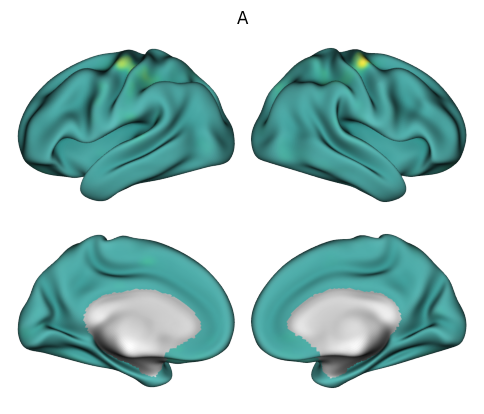

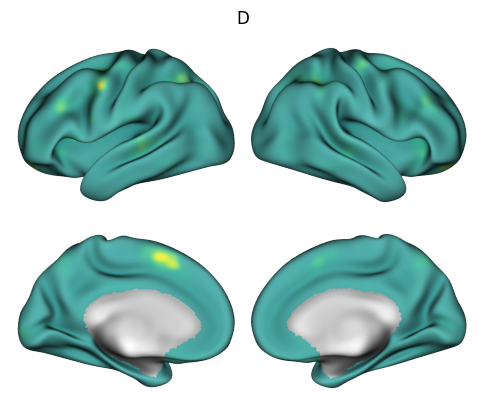

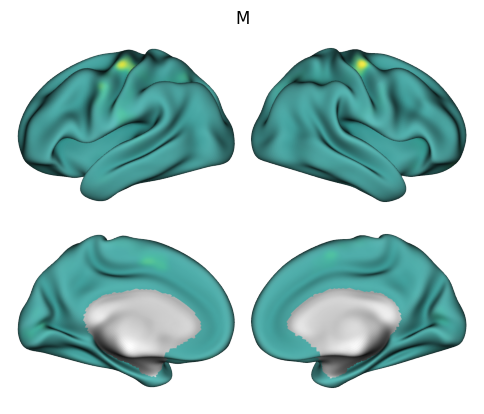

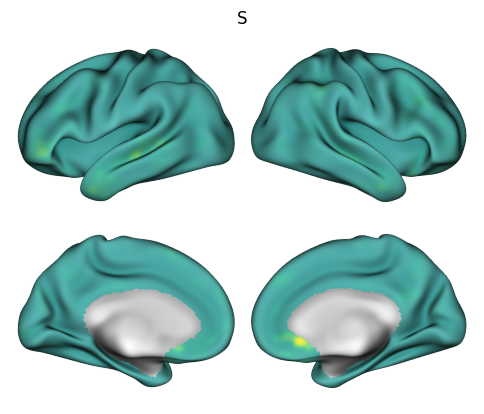

In [11]:
thr = None#3e-5
for i, label in enumerate(labels):
    oname = f'{traindata}_{cortex_roi}_{label}_{method}_mean.dscalar.nii'
    cifti_img_region = nb.load(gl.conn_dir + f"/maps/{oname}")
    # plu.plot_cortex_map(cifti_img_region, cmap='seismic', layout='grid', threshold=thr,
    #                     cbar=False, cscale='sym', alpha=0.8, zero_transparent=False)
    plu.plot_cortex_map(cifti_img_region, cmap='viridis', layout='grid', threshold=thr,
                        cbar=False, cscale='sym', alpha=0.8, zero_transparent=False)
    plt.title(f'{label}');
    plt.show();
    if i==10:
        break;

In [25]:
import os
os.makedirs("./tmp", exist_ok=True)

# save the figures individually
pdf_files = []
for i, label in enumerate(labels):
    oname = f'{traindata}_{cortex_roi}_{label}_{method}_mean.dscalar.nii'
    cifti_img_region = nb.load(gl.conn_dir + f"/maps/{oname}")
    fig = plu.plot_cortex_map(cifti_img_region, cmap='viridis', layout='grid', surface='veryinflated',
                        cbar=False, cscale='sym', alpha=0.9, zero_transparent=False)
    fig.suptitle(f'{label}');

    fig.savefig(f"./tmp/tmp_{label}.pdf", bbox_inches="tight")
    pdf_files.append(f"./tmp/tmp_{label}.pdf")
    plt.close(fig)

# combine all pdfs
from PyPDF2 import PdfMerger
merger = PdfMerger()

for f in pdf_files:
    merger.append(f)

merger.write(gl.fig_dir + f"/cortex_maps_{method}.pdf")
merger.close()

# delete the tmp folder manually